Retrieved 5027 trading days from 2006-09-25 to 2026-09-18

Train period: 2006-09-25 to 2024-09-17 (4525 days)
Test period:  2024-09-18 to 2026-09-18 (502 days)

--- Parameters Estimated from TRAIN Data ---
Daily drift (mu):        0.001006
Daily volatility (sigma): 0.019836
Annualized drift:        25.36%
Annualized volatility:   31.49%

--- Backtest Accuracy: Median Path vs Actual (R / R-squared, as requested) ---
Pearson R:   0.8158
R-squared:   0.5215
RMSE:        $25.34
MAE:         $19.83
NOTE: R-squared can look weak/negative here even for a well-specified model.
      A single simulated path is not designed to track the real price day
      by day -- it is one random draw from a distribution. The calibration
      check below is the more appropriate validation for this model type.

--- Calibration Check (Recommended Validation for Monte Carlo Models) ---
Actual price inside 50% confidence band: 85.5%  (target: ~50%)
Actual price inside 90% confidence band: 99.8%  (target: ~90%)


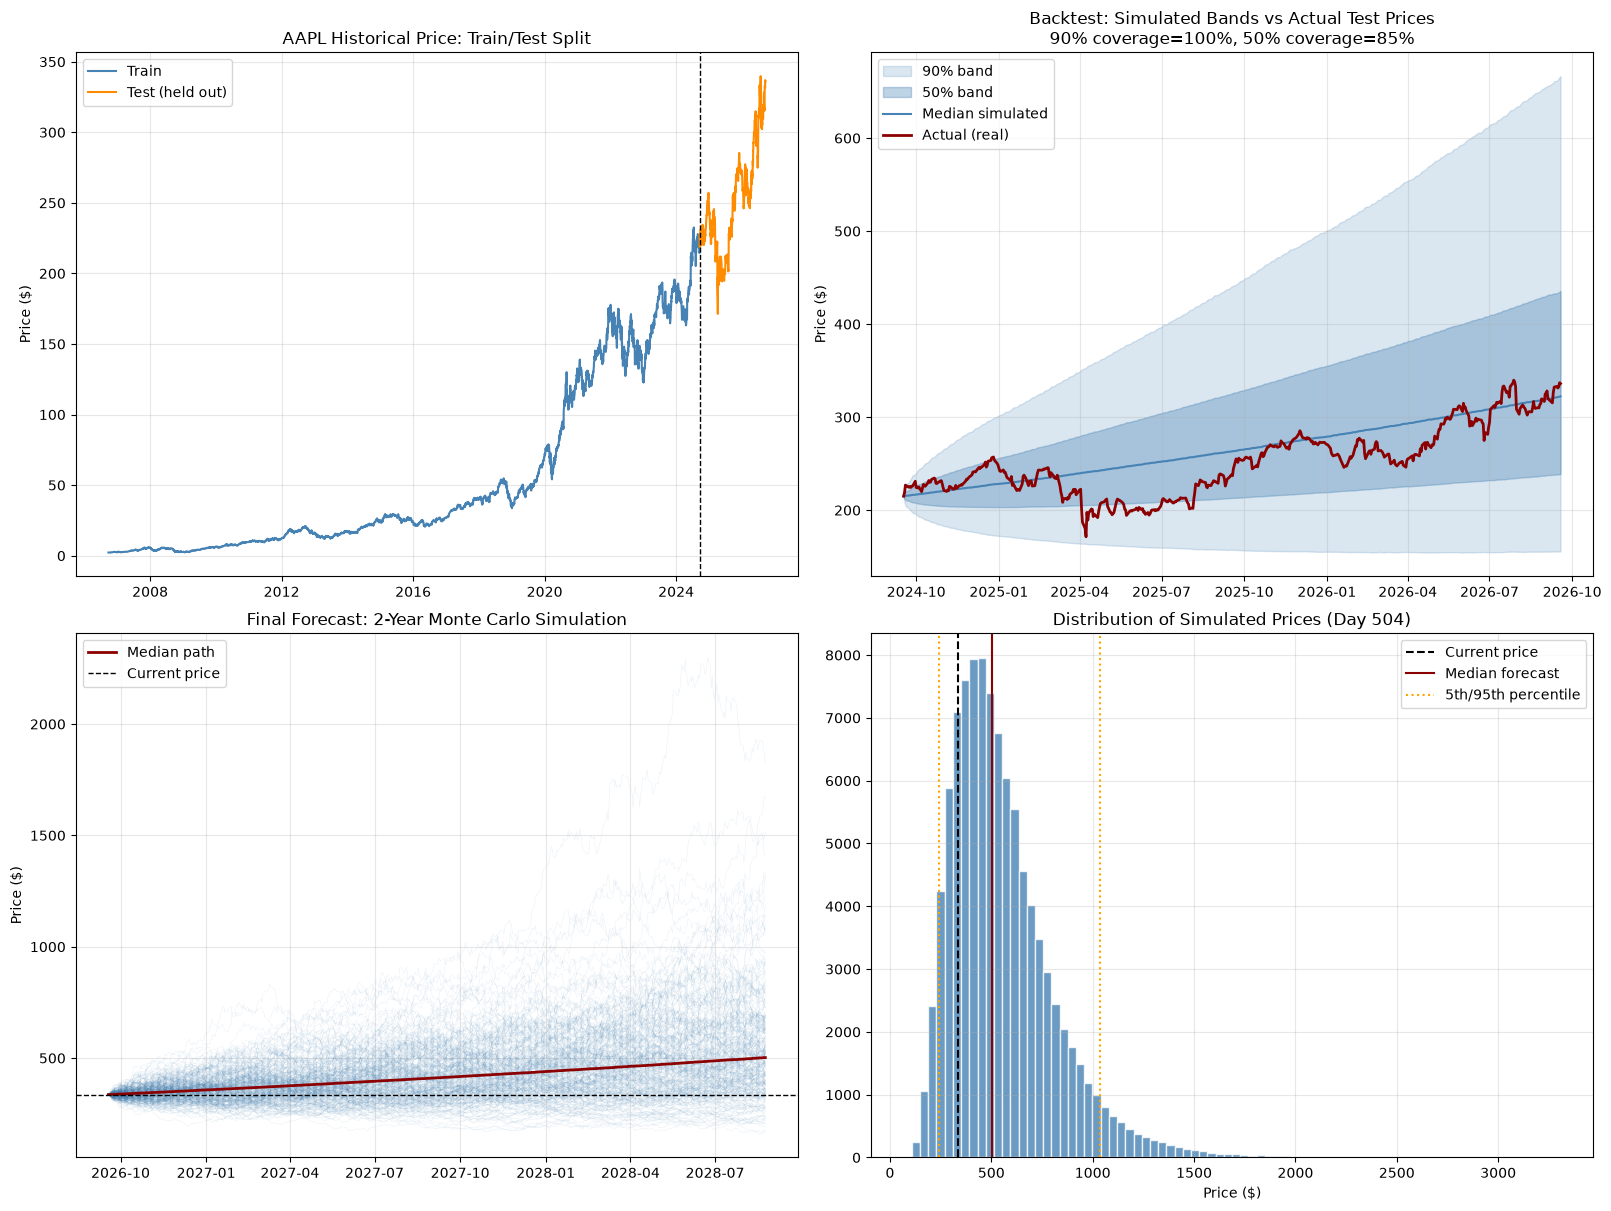

In [2]:
"""
AAPL Stock Price Forecasting using Monte Carlo Simulation (Geometric Brownian Motion)
========================================================================================
PART A - BACKTEST / VALIDATION
    - Splits history into TRAIN (first ~18 years) and TEST (last 2 years, held out)
    - Fits drift (mu) and volatility (sigma) using TRAIN data only
    - Simulates 100,000 forward price paths over the TEST period
    - Compares simulated paths against the REAL, already-known TEST prices using:
        * Pearson correlation (R) and R-squared vs the median simulated path
        * RMSE / MAE vs the median simulated path
        * Calibration / coverage check (the metric that actually matters for a
          Monte Carlo model -- see note printed in the output)
        * Kolmogorov-Smirnov test: do TEST period returns look like they came
          from the same distribution the model assumes (normal log-returns)?
        * Ljung-Box test: are TRAIN period returns free of autocorrelation
          (an assumption GBM relies on)?

PART B - FINAL FORECAST
    - Re-fits mu/sigma using the FULL 20 years of history
    - Simulates 100,000 paths, 2 years into the actual, unknown future
    - Reports expected price, percentile bands, and probability of gain

DISCLAIMER: This is an educational quantitative finance exercise, not investment
advice. GBM/Monte Carlo simulations assume log-returns are normally distributed
and i.i.d. (independent, identically distributed) -- real markets can and do
violate these assumptions (fat tails, volatility clustering, regime shifts,
company-specific news, etc.). Backtest results above are meant to show you
HOW WELL those assumptions held historically, not to guarantee future accuracy.
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from datetime import datetime, timedelta
from scipy.stats import kstest, norm

try:
    from statsmodels.stats.diagnostic import acorr_ljungbox
    HAS_STATSMODELS = True
except ImportError:
    HAS_STATSMODELS = False

# ----------------------------------------------------------------------------
# 1. CONFIGURATION
# ----------------------------------------------------------------------------
TICKER = "AAPL"
YEARS_HISTORY = 20
TEST_YEARS = 2                  # held-out period used ONLY for validation
YEARS_FORECAST = 2              # length of the final, real future forecast
TRADING_DAYS_PER_YEAR = 252
NUM_SIMULATIONS = 100_000       # number of Monte Carlo price paths
RANDOM_SEED = 42                # set to None for different results each run

np.random.seed(RANDOM_SEED)

# ----------------------------------------------------------------------------
# 2. DOWNLOAD HISTORICAL DATA
# ----------------------------------------------------------------------------
end_date = datetime.today()
start_date = end_date - timedelta(days=365 * YEARS_HISTORY)

print(f"Downloading {YEARS_HISTORY} years of {TICKER} data...")
data = yf.download(TICKER, start=start_date, end=end_date, auto_adjust=True, progress=False)

if data.empty:
    raise ValueError("No data downloaded -- check your internet connection or ticker symbol.")

if isinstance(data.columns, pd.MultiIndex):
    data.columns = data.columns.get_level_values(0)

prices = data["Close"].dropna()
print(f"Retrieved {len(prices)} trading days from {prices.index[0].date()} to {prices.index[-1].date()}")

# ----------------------------------------------------------------------------
# 3. TRAIN / TEST SPLIT
# ----------------------------------------------------------------------------
test_start_date = prices.index[-1] - timedelta(days=365 * TEST_YEARS)
train_prices = prices[prices.index < test_start_date]
test_prices = prices[prices.index >= test_start_date]

print(f"\nTrain period: {train_prices.index[0].date()} to {train_prices.index[-1].date()} "
      f"({len(train_prices)} days)")
print(f"Test period:  {test_prices.index[0].date()} to {test_prices.index[-1].date()} "
      f"({len(test_prices)} days)")

# ----------------------------------------------------------------------------
# 4. FIT MODEL PARAMETERS ON TRAIN DATA ONLY
# ----------------------------------------------------------------------------
train_log_returns = np.log(train_prices / train_prices.shift(1)).dropna()
train_mu = train_log_returns.mean()
train_sigma = train_log_returns.std()

print("\n--- Parameters Estimated from TRAIN Data ---")
print(f"Daily drift (mu):        {train_mu:.6f}")
print(f"Daily volatility (sigma): {train_sigma:.6f}")
print(f"Annualized drift:        {train_mu * TRADING_DAYS_PER_YEAR:.2%}")
print(f"Annualized volatility:   {train_sigma * np.sqrt(TRADING_DAYS_PER_YEAR):.2%}")


def simulate_gbm_paths(start_price, mu, sigma, num_days, num_sims, seed=None):
    """Simulate GBM price paths. Returns array of shape (num_days+1, num_sims)."""
    if seed is not None:
        np.random.seed(seed)
    shocks = np.random.normal(
        loc=(mu - 0.5 * sigma**2),
        scale=sigma,
        size=(num_days, num_sims),
    )
    cumulative = np.cumsum(shocks, axis=0)
    paths = start_price * np.exp(cumulative)
    return np.vstack([np.full(num_sims, start_price), paths])


# ----------------------------------------------------------------------------
# 5. BACKTEST: SIMULATE FORWARD OVER THE TEST PERIOD AND COMPARE TO REALITY
# ----------------------------------------------------------------------------
backtest_days = len(test_prices)
backtest_start_price = float(train_prices.iloc[-1])

backtest_paths = simulate_gbm_paths(
    backtest_start_price, train_mu, train_sigma, backtest_days, NUM_SIMULATIONS, seed=RANDOM_SEED
)

median_path = np.median(backtest_paths, axis=1)
p5_path = np.percentile(backtest_paths, 5, axis=1)
p25_path = np.percentile(backtest_paths, 25, axis=1)
p75_path = np.percentile(backtest_paths, 75, axis=1)
p95_path = np.percentile(backtest_paths, 95, axis=1)

actual_test_values = np.concatenate([[backtest_start_price], test_prices.values])

# --- R and R-squared vs the median simulated path (requested metric) ---
r_value = np.corrcoef(actual_test_values, median_path)[0, 1]
r_squared = 1 - np.sum((actual_test_values - median_path) ** 2) / np.sum(
    (actual_test_values - actual_test_values.mean()) ** 2
)
rmse = np.sqrt(np.mean((actual_test_values - median_path) ** 2))
mae = np.mean(np.abs(actual_test_values - median_path))

print("\n--- Backtest Accuracy: Median Path vs Actual (R / R-squared, as requested) ---")
print(f"Pearson R:   {r_value:.4f}")
print(f"R-squared:   {r_squared:.4f}")
print(f"RMSE:        ${rmse:,.2f}")
print(f"MAE:         ${mae:,.2f}")
print("NOTE: R-squared can look weak/negative here even for a well-specified model.")
print("      A single simulated path is not designed to track the real price day")
print("      by day -- it is one random draw from a distribution. The calibration")
print("      check below is the more appropriate validation for this model type.")

# --- Calibration / coverage check (the more meaningful validation) ---
within_50 = np.mean((actual_test_values >= p25_path) & (actual_test_values <= p75_path))
within_90 = np.mean((actual_test_values >= p5_path) & (actual_test_values <= p95_path))

print("\n--- Calibration Check (Recommended Validation for Monte Carlo Models) ---")
print(f"Actual price inside 50% confidence band: {within_50:.1%}  (target: ~50%)")
print(f"Actual price inside 90% confidence band: {within_90:.1%}  (target: ~90%)")
print("Interpretation: if these percentages are close to their targets, the model's")
print("uncertainty bands are well-calibrated historically. If actual coverage is much")
print("lower than target, the model is UNDERSTATING real-world risk (bands too tight).")

# --- Additional statistical checks on model assumptions ---
test_log_returns = np.log(test_prices / test_prices.shift(1)).dropna()

# Kolmogorov-Smirnov: do TEST returns look like they came from the TRAIN-fitted normal dist?
# NOTE: passing a pre-configured frozen distribution's .cdf (rather than "norm" + args=())
# avoids a scipy/numpy version-compatibility bug seen with some recent scipy+numpy pairings.
fitted_normal = norm(loc=train_mu, scale=train_sigma)
ks_stat, ks_pvalue = kstest(test_log_returns, fitted_normal.cdf)
print("\n--- Additional Assumption Checks ---")
print(f"Kolmogorov-Smirnov test (TEST returns vs fitted normal distribution):")
print(f"  statistic={ks_stat:.4f}, p-value={ks_pvalue:.4f}")
print(f"  {'PASS' if ks_pvalue > 0.05 else 'FAIL'}: p > 0.05 means we cannot reject that "
      f"returns are normally distributed as GBM assumes.")

if HAS_STATSMODELS:
    lb_result = acorr_ljungbox(train_log_returns, lags=[10], return_df=True)
    lb_pvalue = lb_result["lb_pvalue"].iloc[0]
    print(f"\nLjung-Box test (TRAIN returns autocorrelation, lag=10):")
    print(f"  p-value={lb_pvalue:.4f}")
    print(f"  {'PASS' if lb_pvalue > 0.05 else 'FAIL'}: p > 0.05 means no significant "
          f"autocorrelation detected, consistent with GBM's independence assumption.")
else:
    print("\n(Install 'statsmodels' to also run a Ljung-Box autocorrelation test: "
          "pip install statsmodels)")

# ----------------------------------------------------------------------------
# 6. FINAL FORECAST: RE-FIT ON FULL 20-YEAR HISTORY, SIMULATE REAL FUTURE
# ----------------------------------------------------------------------------
full_log_returns = np.log(prices / prices.shift(1)).dropna()
full_mu = full_log_returns.mean()
full_sigma = full_log_returns.std()
current_price = float(prices.iloc[-1])

forecast_days = int(TRADING_DAYS_PER_YEAR * YEARS_FORECAST)
forecast_paths = simulate_gbm_paths(
    current_price, full_mu, full_sigma, forecast_days, NUM_SIMULATIONS, seed=RANDOM_SEED
)

terminal_prices = forecast_paths[-1]
expected_price = terminal_prices.mean()
median_price = np.median(terminal_prices)
f_p5, f_p25, f_p75, f_p95 = np.percentile(terminal_prices, [5, 25, 75, 95])
prob_above_current = (terminal_prices > current_price).mean()

print(f"\n--- Final Forecast: {YEARS_FORECAST}-Year Horizon (fit on full {YEARS_HISTORY}-year "
      f"history, {NUM_SIMULATIONS:,} simulations) ---")
print(f"Current price:               ${current_price:,.2f}")
print(f"Expected price:               ${expected_price:,.2f}")
print(f"Median price:                 ${median_price:,.2f}")
print(f"5th percentile (bear case):   ${f_p5:,.2f}")
print(f"25th percentile:              ${f_p25:,.2f}")
print(f"75th percentile:              ${f_p75:,.2f}")
print(f"95th percentile (bull case):  ${f_p95:,.2f}")
print(f"Probability price > today:    {prob_above_current:.1%}")

# ----------------------------------------------------------------------------
# 7. VISUALIZATION
# ----------------------------------------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(16, 12), constrained_layout=True)

# --- Plot 1: Full historical price with train/test split marked ---
axes[0, 0].plot(train_prices.index, train_prices.values, color="steelblue", label="Train")
axes[0, 0].plot(test_prices.index, test_prices.values, color="darkorange", label="Test (held out)")
axes[0, 0].axvline(test_start_date, color="black", linestyle="--", linewidth=1)
axes[0, 0].set_title(f"{TICKER} Historical Price: Train/Test Split")
axes[0, 0].set_ylabel("Price ($)")
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

# --- Plot 2: Backtest -- simulated bands vs actual test prices ---
test_dates = pd.DatetimeIndex([train_prices.index[-1]]).append(test_prices.index)
axes[0, 1].fill_between(test_dates, p5_path, p95_path, color="steelblue", alpha=0.2, label="90% band")
axes[0, 1].fill_between(test_dates, p25_path, p75_path, color="steelblue", alpha=0.35, label="50% band")
axes[0, 1].plot(test_dates, median_path, color="steelblue", linewidth=1.5, label="Median simulated")
axes[0, 1].plot(test_dates, actual_test_values, color="darkred", linewidth=2, label="Actual (real)")
axes[0, 1].set_title(f"Backtest: Simulated Bands vs Actual Test Prices\n"
                      f"90% coverage={within_90:.0%}, 50% coverage={within_50:.0%}")
axes[0, 1].set_ylabel("Price ($)")
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)

# --- Plot 3: Final forecast fan chart ---
future_dates = pd.bdate_range(start=prices.index[-1], periods=forecast_days + 1)
sample_paths = min(300, NUM_SIMULATIONS)
axes[1, 0].plot(future_dates, forecast_paths[:, :sample_paths], linewidth=0.4, alpha=0.1, color="steelblue")
axes[1, 0].plot(future_dates, np.median(forecast_paths, axis=1), color="darkred", linewidth=2, label="Median path")
axes[1, 0].axhline(current_price, color="black", linestyle="--", linewidth=1, label="Current price")
axes[1, 0].set_title(f"Final Forecast: {YEARS_FORECAST}-Year Monte Carlo Simulation")
axes[1, 0].set_ylabel("Price ($)")
axes[1, 0].legend()
axes[1, 0].grid(alpha=0.3)

# --- Plot 4: Distribution of final terminal prices ---
axes[1, 1].hist(terminal_prices, bins=80, color="steelblue", edgecolor="white", alpha=0.8)
axes[1, 1].axvline(current_price, color="black", linestyle="--", label="Current price")
axes[1, 1].axvline(median_price, color="darkred", linestyle="-", label="Median forecast")
axes[1, 1].axvline(f_p5, color="orange", linestyle=":", label="5th/95th percentile")
axes[1, 1].axvline(f_p95, color="orange", linestyle=":")
axes[1, 1].set_title(f"Distribution of Simulated Prices (Day {forecast_days})")
axes[1, 1].set_xlabel("Price ($)")
axes[1, 1].legend()
axes[1, 1].grid(alpha=0.3)

plt.savefig("aapl_monte_carlo_results.png", dpi=150)
print("\nChart saved as 'aapl_monte_carlo_results.png' in your working directory.")
plt.show()